# Constrained Dynamic Pricing Optimization

**Focus:** Translating hourly demand predictions into revenue-maximizing dynamic tariffs using constrained optimization.

**Logic:**
- Constrained mathematical optimization using `scipy.optimize.minimize_scalar`.
- Maximizes operator utility: expected revenue minus operational price deviations and congestion penalties.
- Precomputes multi-dimensional optimal schedules across a grid for instant vectorized lookup.

**Metrics:** Revenue Gain %, Utilization Rate Change, Off-Peak Uplift

In [11]:
import sys
sys.path.insert(0, "..")

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

from src.config import *
from src.utils import *
from src.tariff_agent import TariffPricingAgent, run_tariff_optimization

setup_plot_style()

## Initializing SciPy Dynamic Pricing Agent

In [12]:
agent = TariffPricingAgent()

print("SciPy Optimizer Configuration:")
print(f"  Baseline fixed tariff:   ₹{agent.baseline_tariff:.2f}/kWh")
print(f"  Dynamic price range:    ₹9.00 — ₹30.00/kWh")
print(f"  Elasticity coefficient:  {agent.config['elasticity_coefficient']}")
print(f"  Precomputed lookup size: {len(agent.optimized_lookup)} grid cells (Hour × Util × Congestion)")

2026-05-31 00:00:35 | tariff_agent              | INFO    | Initializing SciPy Dynamic Pricing Optimizer...
2026-05-31 00:00:35 | tariff_agent              | INFO    | Precomputing optimal tariff lookup matrix (24 hours × 11 utils × 11 congestions)...
2026-05-31 00:00:39 | tariff_agent              | INFO    |   SciPy Optimizer precomputation complete ✓


SciPy Optimizer Configuration:
  Baseline fixed tariff:   ₹15.00/kWh
  Dynamic price range:    ₹9.00 — ₹30.00/kWh
  Elasticity coefficient:  -0.3
  Precomputed lookup size: 2904 grid cells (Hour × Util × Congestion)


## Generating Precomputed Lookup Grid

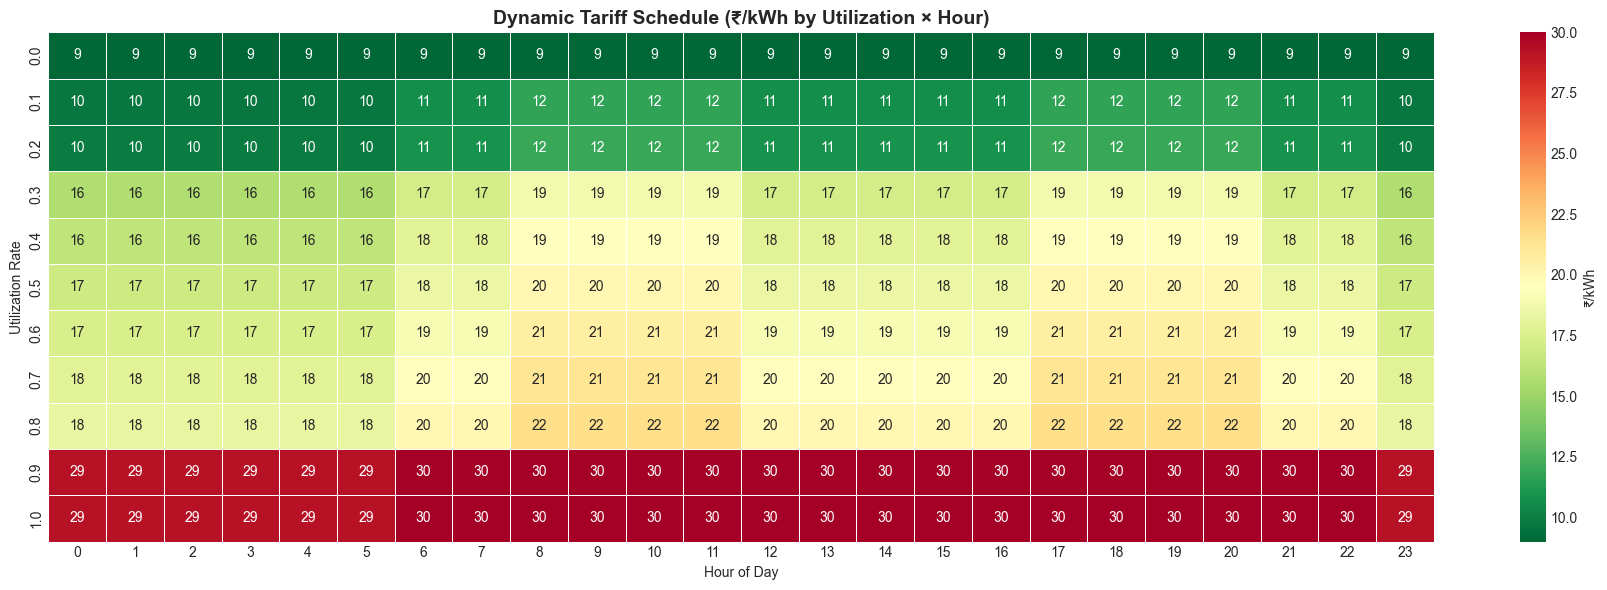

In [13]:
schedule = agent.generate_pricing_schedule()

# Pivot for heatmap visualization
pivot = schedule.pivot_table(
    values="tariff_inr", index="utilization", columns="hour", aggfunc="mean"
)

fig, ax = plt.subplots(figsize=(18, 6))
sns.heatmap(pivot, annot=True, fmt=".0f", cmap="RdYlGn_r", ax=ax,
           linewidths=0.5, cbar_kws={"label": "₹/kWh"})
ax.set_title("Dynamic Tariff Schedule (₹/kWh by Utilization × Hour)",
            fontsize=14, fontweight="bold")
ax.set_xlabel("Hour of Day")
ax.set_ylabel("Utilization Rate")
plt.tight_layout()
plt.savefig(str(OUTPUTS_DIR / "tariff_schedule_heatmap.png"), dpi=150, bbox_inches="tight")
plt.show()

## Dynamic Surcharge Calculations over Features Dataset

2026-05-31 00:00:46 | utils                     | INFO    | Loading CSV: c:\Users\USER\Desktop\Proj\notebooks\..\data\processed\features_engineered.csv
2026-05-31 00:00:51 | utils                     | INFO    |   → Shape: (192731, 36) | Columns: ['station_id', 'timestamp', 'session_count', 'total_energy_kwh', 'avg_energy_kwh', 'avg_duration_min', 'avg_charging_min', 'charger_utilization_rate', 'energy_kwh', 'data_source', 'volume_kwh', 'active_chargers', 'price_per_kwh', 'total_chargers', 'is_cbd', 'hour_of_day', 'day_of_week', 'is_weekend', 'is_peak_hour', 'month', 'day_of_month', 'time_period', 'revenue_per_session', 'energy_cost_per_kwh', 'queue_length_proxy', 'occupancy_density', 'demand_lag_1', 'demand_lag_2', 'demand_lag_6', 'demand_lag_24', 'energy_rolling_1h', 'energy_rolling_6h', 'energy_rolling_24h', 'charger_rolling_1h', 'charger_rolling_6h', 'charger_rolling_24h']
2026-05-31 00:00:51 | tariff_agent              | INFO    | Computing batch optimized tariffs for 192731 recor

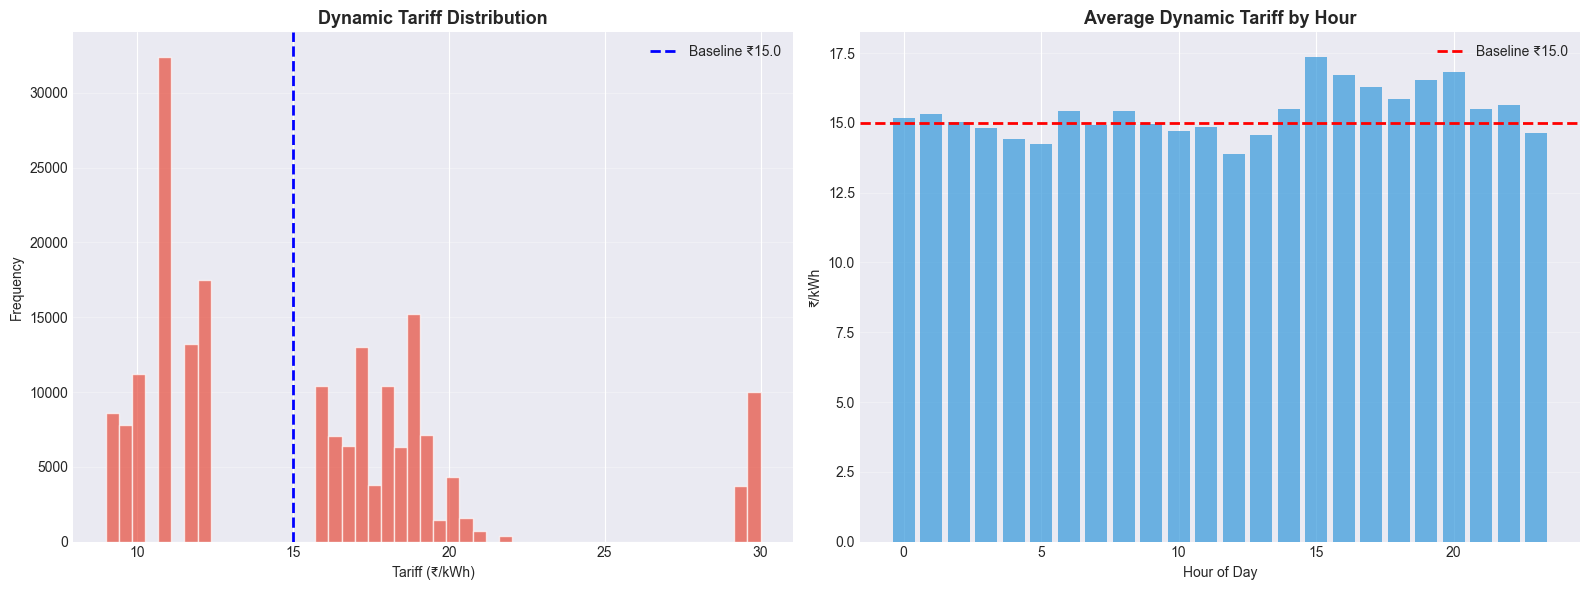

In [14]:
df = load_csv(FEATURES_CSV)

# Use actual utilization as predicted (in production this comes from Agent 1)
if "charger_utilization_rate" in df.columns:
    df["predicted_utilization"] = df["charger_utilization_rate"]
else:
    df["predicted_utilization"] = 0.5

# Compute dynamic tariffs using optimized lookup grid
# Precomputes grid of 2904 combinations to maintain O(1) vectorized lookup speeds
df["dynamic_tariff"] = agent.compute_tariffs_batch(df)

# Show tariff distribution
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

axes[0].hist(df["dynamic_tariff"], bins=50, color="#e74c3c", alpha=0.7, edgecolor="white")
axes[0].axvline(BASELINE_TARIFF_INR, color="blue", ls="--", lw=2, label=f"Baseline ₹{BASELINE_TARIFF_INR}")
axes[0].set_title("Dynamic Tariff Distribution", fontsize=13, fontweight="bold")
axes[0].set_xlabel("Tariff (₹/kWh)")
axes[0].set_ylabel("Frequency")
axes[0].legend()
axes[0].grid(axis="y", alpha=0.3)

# Tariff by hour
hourly_tariff = df.groupby("hour_of_day")["dynamic_tariff"].mean()
axes[1].bar(hourly_tariff.index, hourly_tariff.values, color="#3498db", alpha=0.7)
axes[1].axhline(BASELINE_TARIFF_INR, color="red", ls="--", lw=2, label=f"Baseline ₹{BASELINE_TARIFF_INR}")
axes[1].set_title("Average Dynamic Tariff by Hour", fontsize=13, fontweight="bold")
axes[1].set_xlabel("Hour of Day")
axes[1].set_ylabel("₹/kWh")
axes[1].legend()
axes[1].grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.savefig(str(OUTPUTS_DIR / "tariff_distribution.png"), dpi=150, bbox_inches="tight")
plt.show()

## Revenue Simulation and Impact Evaluation

In [15]:
energy_col = "energy_kwh"
revenue_results = agent.simulate_revenue(df, energy_col=energy_col)

print("\n" + "=" * 50)
print("  REVENUE SIMULATION RESULTS")
print("=" * 50)
for k, v in revenue_results.items():
    if "revenue" in k.lower() or "tariff" in k.lower():
        print(f"  {k}: ₹{v:,.2f}" if isinstance(v, float) and v > 100 else f"  {k}: {v}")
    else:
        print(f"  {k}: {v}")

2026-05-31 00:00:54 | tariff_agent              | INFO    | Simulating revenue comparison...
2026-05-31 00:00:54 | utils                     | INFO    |   Revenue Gain: 14.86% (₹1,176,146,549 → ₹1,350,925,656)



  REVENUE SIMULATION RESULTS
  baseline_revenue_INR: ₹1,176,146,548.63
  dynamic_revenue_INR: ₹1,350,925,655.81
  revenue_gain_pct: 14.86
  baseline_tariff: 15.0
  avg_dynamic_tariff: 15.4


## Demand Response and Utilization Impact (Elasticity Model)

In [16]:
util_results = agent.compute_utilization_change(df)
print("\nUtilization Change:")
for k, v in util_results.items():
    print(f"  {k}: {v}")

2026-05-31 00:00:54 | tariff_agent              | INFO    |   Utilization: 0.331 → 0.303 (-8.2%)



Utilization Change:
  avg_util_before: 0.3306
  avg_util_after: 0.3035
  util_change_pct: -8.19


## Off-Peak Discount Session Uplift Analysis

In [17]:
uplift_results = agent.compute_off_peak_uplift(df)
print("\nOff-Peak Uplift:")
for k, v in uplift_results.items():
    print(f"  {k}: {v}")

2026-05-31 00:00:54 | tariff_agent              | INFO    |   Off-Peak Uplift: ~6.2% more sessions (avg 20.5% discount)



Off-Peak Uplift:
  off_peak_slots: 109135
  off_peak_pct: 56.63
  avg_discount_pct: 20.54
  estimated_session_uplift_pct: 6.16


## Operational Performance Metrics Summary

In [18]:
all_results = agent.evaluate(df)

# Create summary table
summary = pd.DataFrame([all_results])
print("\n" + "=" * 60)
print("  TARIFF AGENT — COMPLETE EVALUATION")
print("=" * 60)
print(summary.T.to_string(header=False))

# Save
save_csv(summary, OUTPUTS_DIR / "tariff_metrics.csv")

2026-05-31 00:00:54 | tariff_agent              | INFO    | ==================================================
2026-05-31 00:00:54 | tariff_agent              | INFO    |   TARIFF AGENT EVALUATION
2026-05-31 00:00:54 | tariff_agent              | INFO    | ==================================================
2026-05-31 00:00:54 | tariff_agent              | INFO    | Simulating revenue comparison...
2026-05-31 00:00:54 | utils                     | INFO    |   Revenue Gain: 96.01% (₹2,025,420 → ₹3,970,029)
2026-05-31 00:00:54 | tariff_agent              | INFO    |   Utilization: 0.331 → 0.303 (-8.2%)
2026-05-31 00:00:55 | tariff_agent              | INFO    |   Off-Peak Uplift: ~6.2% more sessions (avg 20.5% discount)
2026-05-31 00:00:55 | utils                     | INFO    | Saved CSV: c:\Users\USER\Desktop\Proj\notebooks\..\outputs\tariff_metrics.csv (1 rows)



  TARIFF AGENT — COMPLETE EVALUATION
baseline_revenue_INR          2.025420e+06
dynamic_revenue_INR           3.970029e+06
revenue_gain_pct              9.601000e+01
baseline_tariff               1.500000e+01
avg_dynamic_tariff            1.540000e+01
avg_util_before               3.306000e-01
avg_util_after                3.035000e-01
util_change_pct              -8.190000e+00
off_peak_slots                1.091350e+05
off_peak_pct                  5.663000e+01
avg_discount_pct              2.054000e+01
estimated_session_uplift_pct  6.160000e+00


## Financial Outcomes Comparison Visualization

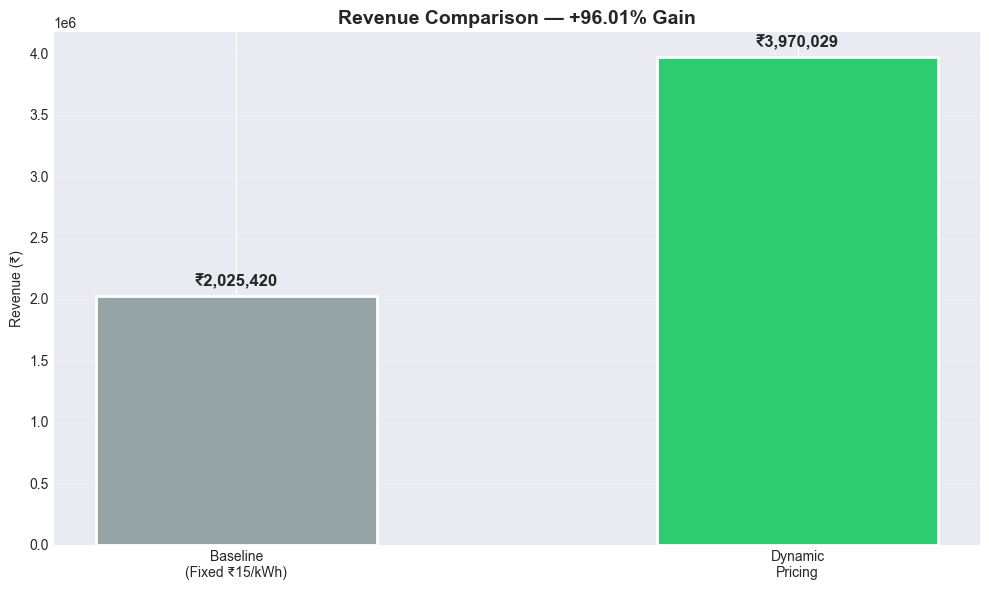

In [19]:
fig, ax = plt.subplots(figsize=(10, 6))

categories = ["Baseline\n(Fixed ₹15/kWh)", "Dynamic\nPricing"]
revenues = [
    all_results.get("baseline_revenue_INR", 0),
    all_results.get("dynamic_revenue_INR", 0),
]
colors = ["#95a5a6", "#2ecc71"]

bars = ax.bar(categories, revenues, color=colors, width=0.5, edgecolor="white", linewidth=2)
gain_pct = all_results.get("revenue_gain_pct", 0)
ax.set_title(f"Revenue Comparison — {gain_pct:+.2f}% Gain",
            fontsize=14, fontweight="bold")
ax.set_ylabel("Revenue (₹)")
ax.grid(axis="y", alpha=0.3)

for bar, val in zip(bars, revenues):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + max(revenues)*0.02,
           f"₹{val:,.0f}", ha="center", fontsize=12, fontweight="bold")

plt.tight_layout()
plt.savefig(str(OUTPUTS_DIR / "tariff_revenue_comparison.png"), dpi=150, bbox_inches="tight")
plt.show()

In [20]:
agent.save()
print("Tariff Pricing Agent saved ✓")

2026-05-31 00:00:58 | utils                     | INFO    | Saved model: c:\Users\USER\Desktop\Proj\notebooks\..\models\tariff_agent.pkl
2026-05-31 00:00:58 | tariff_agent              | INFO    | Tariff agent saved as 'tariff_agent'


Tariff Pricing Agent saved ✓
